In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [7]:
# CustomerID 제거, 성별 인코딩
df=pd.read_csv('./data/Mall_Customers.csv')
df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values


In [8]:
X

array([[ 19,  15,  39,   1],
       [ 21,  15,  81,   1],
       [ 20,  16,   6,   0],
       [ 23,  16,  77,   0],
       [ 31,  17,  40,   0],
       [ 22,  17,  76,   0],
       [ 35,  18,   6,   0],
       [ 23,  18,  94,   0],
       [ 64,  19,   3,   1],
       [ 30,  19,  72,   0],
       [ 67,  19,  14,   1],
       [ 35,  19,  99,   0],
       [ 58,  20,  15,   0],
       [ 24,  20,  77,   0],
       [ 37,  20,  13,   1],
       [ 22,  20,  79,   1],
       [ 35,  21,  35,   0],
       [ 20,  21,  66,   1],
       [ 52,  23,  29,   1],
       [ 35,  23,  98,   0],
       [ 35,  24,  35,   1],
       [ 25,  24,  73,   1],
       [ 46,  25,   5,   0],
       [ 31,  25,  73,   1],
       [ 54,  28,  14,   0],
       [ 29,  28,  82,   1],
       [ 45,  28,  32,   0],
       [ 35,  28,  61,   1],
       [ 40,  29,  31,   0],
       [ 23,  29,  87,   0],
       [ 60,  30,   4,   1],
       [ 21,  30,  73,   0],
       [ 53,  33,   4,   1],
       [ 18,  33,  92,   1],
       [ 49,  

In [9]:
# StandardScaler로 x 스케일링
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
# PCA : 2개의 주성분으로 압축
# 4. PCA : 2개의 주성분으로 압축
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# PCA 결과를 데이터프레임으로 변환
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
# KMEANS 클러스터링 

# 5. K-Means 클러스터링 (k=5 가정)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
df_pca['Cluster'] = kmeans.fit_transform(pca_data).argmax(axis=1) # 혹은 kmeans.labels_

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


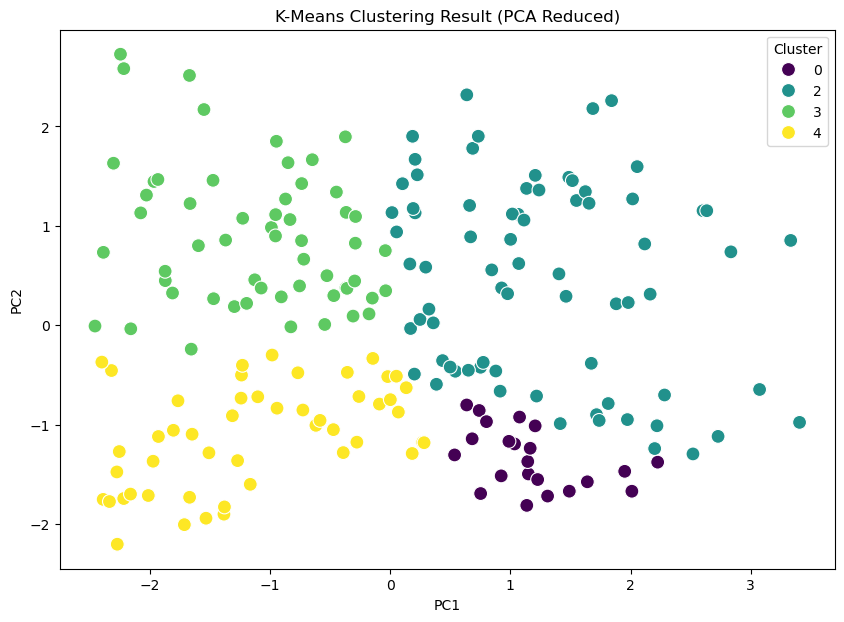

In [18]:
# KMeans 클러스터링 결과 시각화
# 6. KMeans 클러스터링 결과 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)
plt.title('K-Means Clustering Result (PCA Reduced)')
plt.show()

--- 군집별 특징(평균값) ---
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         60.800000  0.490909  54.654545           44.181818   
1        104.212766  0.382979  31.446809           61.851064   
2         26.156250  0.312500  26.156250           27.593750   
3        169.870968  0.419355  31.935484           90.451613   
4        164.428571  0.571429  41.685714           88.228571   

         Spending Score (1-100)  
Cluster                          
0                     38.800000  
1                     54.553191  
2                     67.593750  
3                     83.032258  
4                     17.285714  


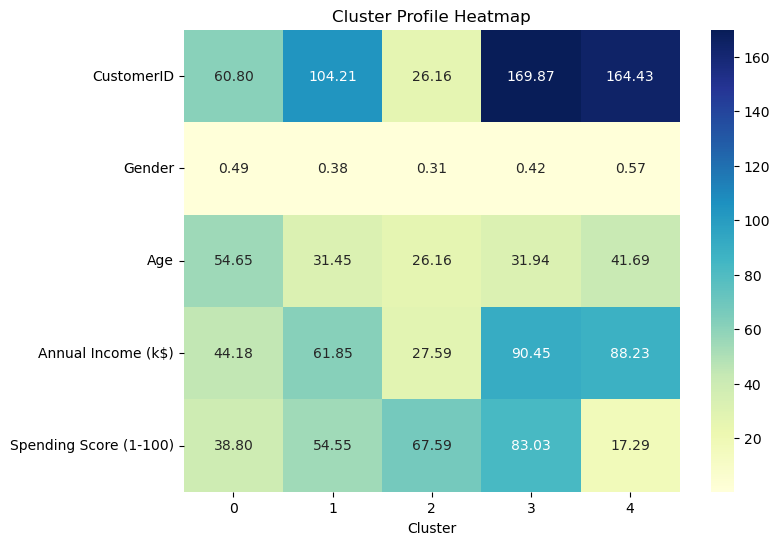

In [19]:
# 원본 데이터(df)에 군집 결과 추가
df['Cluster'] = kmeans.labels_

# 군집별 평균 데이터 계산 (성별은 비중으로 해석 가능)
cluster_analysis = df.groupby('Cluster').mean()

print("--- 군집별 특징(평균값) ---")
print(cluster_analysis)

# 시각적으로 확인하기 위한 히트맵 (선택 사항)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_analysis.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Profile Heatmap')
plt.show()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

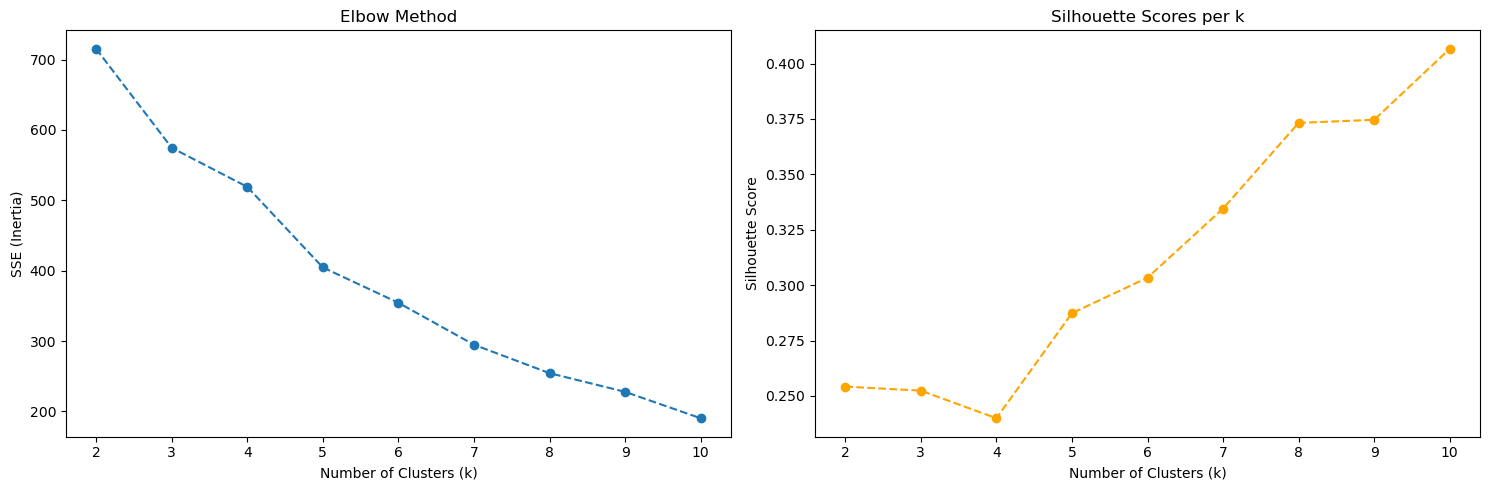

In [20]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# SSE와 실루엣 점수를 저장할 리스트
sse = []
silhouette_coefficients = []

# k를 2부터 10까지 변화시키며 측정
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    
    # 1. 엘보우 방법을 위한 SSE(Inertia) 저장
    sse.append(kmeans.inertia_)
    
    # 2. 실루엣 점수 계산 및 저장
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

# 시각화
plt.figure(figsize=(15, 5))

# 엘보우 방법 그래프
plt.subplot(1, 2, 1)
plt.plot(K_range, sse, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')

# 실루엣 점수 그래프
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_coefficients, marker='o', linestyle='--', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores per k')

plt.tight_layout()
plt.show()